<a href="https://colab.research.google.com/github/srisham7/single_photon_as_qubits/blob/main/Linearly_and_Circularly_polarized_light.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install py-pol

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.6/144.6 kB 3.1 MB/s eta 0:00:00


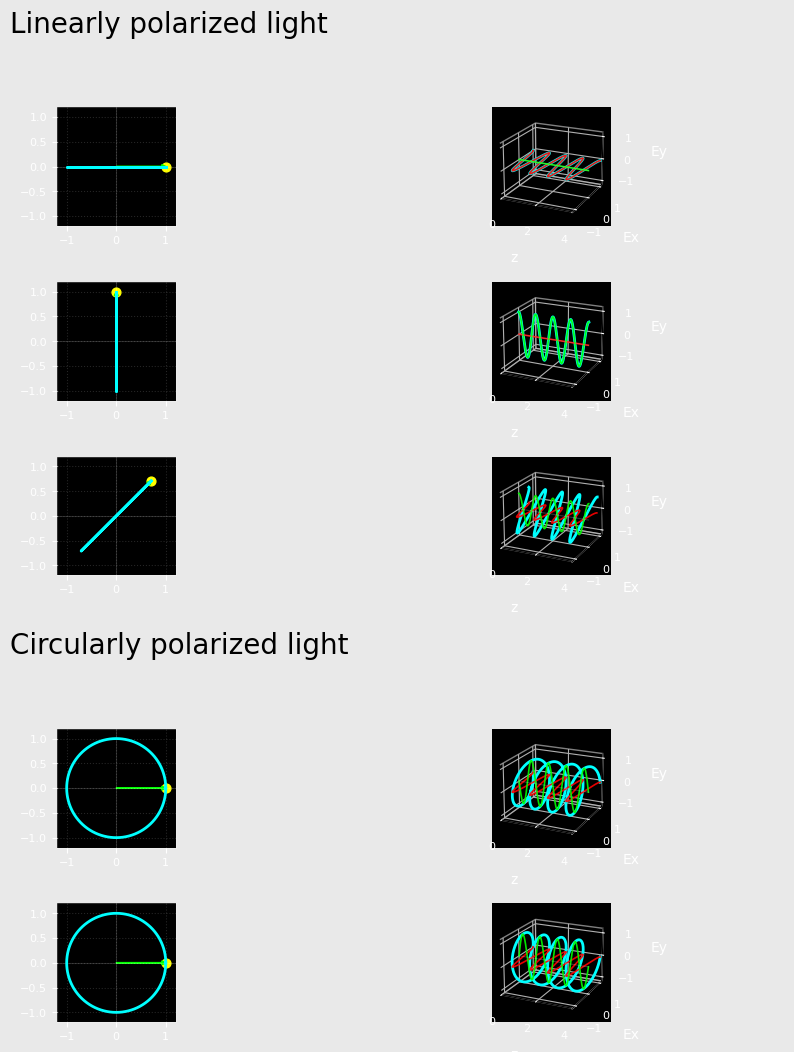

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# core model
def polarization_field(z, Ax=1.0, Ay=1.0, phix=0.0, phiy=0.0, k=2*np.pi, t=0.0):
    psi = k * z - t
    Ex = Ax * np.cos(psi + phix)
    Ey = Ay * np.cos(psi + phiy)
    return Ex, Ey

# state definitions
states_linear = [
    ("Horizontal", dict(Ax=1.0, Ay=0.0, phix=0.0, phiy=0.0)),
    ("Vertical",   dict(Ax=0.0, Ay=1.0, phix=0.0, phiy=0.0)),
    ("Diagonal",   dict(Ax=1/np.sqrt(2), Ay=1/np.sqrt(2), phix=0.0, phiy=0.0)),
]

states_circular = [
    ("Right circular", dict(Ax=1.0, Ay=1.0, phix=0.0, phiy=np.pi/2)),
    ("Left circular",  dict(Ax=1.0, Ay=1.0, phix=0.0, phiy=-np.pi/2)),
]

#plot helpers
def style_2d(ax, lim=1.2):
    ax.set_facecolor("black")
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")
    ax.grid(True, color="white", alpha=0.15, linestyle=":")
    for spine in ax.spines.values():
        spine.set_color("white")
        spine.set_alpha(0.2)
    ax.tick_params(colors="white", labelsize=8)
    ax.axhline(0, color="white", alpha=0.15, lw=0.8)
    ax.axvline(0, color="white", alpha=0.15, lw=0.8)

def style_3d(ax):
    ax.set_facecolor("black")
    ax.xaxis.pane.set_facecolor((0, 0, 0, 1))
    ax.yaxis.pane.set_facecolor((0, 0, 0, 1))
    ax.zaxis.pane.set_facecolor((0, 0, 0, 1))
    ax.xaxis.pane.set_edgecolor((1, 1, 1, 0.15))
    ax.yaxis.pane.set_edgecolor((1, 1, 1, 0.15))
    ax.zaxis.pane.set_edgecolor((1, 1, 1, 0.15))
    ax.grid(True, color="white", alpha=0.1)
    ax.tick_params(colors="white", labelsize=8)
    ax.set_xlabel("z", color="white", labelpad=6)
    ax.set_ylabel("Ex", color="white", labelpad=6)
    ax.set_zlabel("Ey", color="white", labelpad=6)

def plot_front_view(ax, params, z0=0.0):
    t = np.linspace(0, 2*np.pi, 500)

    Ex, Ey = polarization_field(
        z0,
        Ax=params["Ax"], Ay=params["Ay"],
        phix=params["phix"], phiy=params["phiy"],
        k=2*np.pi, t=t
    )

    style_2d(ax)

    # trayectoria temporal en un punto fijo del espacio
    ax.plot(Ex, Ey, color="cyan", lw=2)

    # punto actual en t=0
    Ex0, Ey0 = polarization_field(
        z0,
        Ax=params["Ax"], Ay=params["Ay"],
        phix=params["phix"], phiy=params["phiy"],
        k=2*np.pi, t=np.array([0.0])
    )

    ax.scatter(Ex0, Ey0, color="yellow", s=40)

    ax.arrow(
        0, 0, Ex0[0], Ey0[0],
        color="lime", width=0.01,
        head_width=0.08, head_length=0.08,
        length_includes_head=True
    )

def plot_wave_view(ax, params):
    z = np.linspace(0, 4, 700)
    Ex, Ey = polarization_field(
        z,
        Ax=params["Ax"], Ay=params["Ay"],
        phix=params["phix"], phiy=params["phiy"],
        k=2*np.pi, t=0.0
    )

    style_3d(ax)

    #trajectory: (z, Ex, Ey)
    ax.plot(z, Ex, Ey, color="cyan", lw=2)

    # Component curves
    ax.plot(z, Ex, np.zeros_like(z), color="red", lw=1.2, alpha=0.9)
    ax.plot(z, np.zeros_like(z), Ey, color="lime", lw=1.2, alpha=0.9)

    # guide rails
    ax.plot(z, np.zeros_like(z), np.zeros_like(z), color="white", lw=0.8, alpha=0.2)

    ax.set_xlim(0, 4)
    ax.set_ylim(-1.2, 1.2)
    ax.set_zlim(-1.2, 1.2)
    ax.view_init(elev=20, azim=-65)

#figure layout
fig = plt.figure(figsize=(10, 14), facecolor="#e9e9e9")
gs = GridSpec(
    nrows=8, ncols=2, figure=fig,
    height_ratios=[0.35, 1, 1, 1, 0.35, 1, 1, 0.08],
    width_ratios=[1, 2.2],
    hspace=0.65, wspace=0.28
)

ax_t1 = fig.add_subplot(gs[0, :])
ax_t1.axis("off")
ax_t1.text(0.0, 0.45, "Linearly polarized light", fontsize=20, color="black")

# linear rows
for i, (name, params) in enumerate(states_linear, start=1):
    ax_front = fig.add_subplot(gs[i, 0])
    ax_wave = fig.add_subplot(gs[i, 1], projection="3d")
    plot_front_view(ax_front, params)
    plot_wave_view(ax_wave, params)


ax_t2 = fig.add_subplot(gs[4, :])
ax_t2.axis("off")
ax_t2.text(0.0, 0.45, "Circularly polarized light", fontsize=20, color="black")

# circular rows
for i, (name, params) in enumerate(states_circular, start=5):
    ax_front = fig.add_subplot(gs[i, 0])
    ax_wave = fig.add_subplot(gs[i, 1], projection="3d")
    plot_front_view(ax_front, params)
    plot_wave_view(ax_wave, params)

plt.show()